## 1. Scope the Project

Our plan is to use a supervised learning technique to predict which customers are most likely to cancel their subscription using **the past three months of customer data which includes subscription and listening history**.

## 2. Gather Data

We are going to read the projects data files in Python:
* Customer data: *maven_music_customers.csv*
* Listing history: *maven_music_listening_history.xlsx*

In [112]:
import pandas as pd
import numpy as np

In [113]:
customers = pd.read_csv(r"maven_music_customers.csv")
listening_history = pd.read_excel(r"maven_music_listening_history.xlsx")

In [114]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN


In [115]:
listening_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [116]:
audio = pd.read_excel(r"maven_music_listening_history.xlsx", sheet_name="audio_files")
audio.head()

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52


In [117]:
# Read in the session data
session_data = pd.read_excel(r"maven_music_listening_history.xlsx", sheet_name='session_login_time')
session_data.head()

,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00


In [118]:
listening_history

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song
...,...,...,...,...,...
500,7579,111282,4,111,Song
501,6588,111286,1,201,Podcast
502,5763,111333,1,110,Song
503,5763,111333,2,108,Song


## 3. Clean Data

### a. Convert Data Types

1. Customers dataset

In [119]:
customers.dtypes

Customer ID          int64
Customer Name          str
Email                  str
Member Since           str
Subscription Plan      str
Subscription Rate      str
Discount?              str
Cancellation Date      str
dtype: object

In [120]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN


In [121]:
customers["Subscription Rate"]= pd.to_numeric(customers["Subscription Rate"].str.replace("$", ""))

In [122]:
customers["Member Since"] = pd.to_datetime(customers["Member Since"])

C:\Users\dguer\AppData\Local\Temp\ipykernel_14636\2107546918.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customers["Member Since"] = pd.to_datetime(customers["Member Since"])


In [123]:
customers["Cancellation Date"] = pd.to_datetime(customers["Cancellation Date"])

C:\Users\dguer\AppData\Local\Temp\ipykernel_14636\3199408394.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customers["Cancellation Date"] = pd.to_datetime(customers["Cancellation Date"])


2. Audio dataset

In [124]:
audio.dtypes

ID              str
Name            str
Genre           str
Popularity    int64
dtype: object

3. listening history dataset

In [125]:
listening_history.dtypes

Customer ID    int64
Session ID     int64
Audio Order    int64
Audio ID       int64
Audio Type       str
dtype: object

4. Session dataset

In [126]:
session_data.dtypes

Session ID                      int64
Session Log In Time    datetime64[us]
dtype: object

### b. Resolve Data Issues

#### i. Missing Data

1. Customers dataset

In [127]:
# Look for NaN values in the data
customers.isna().sum()


Customer ID           0
Customer Name         0
Email                 0
Member Since          0
Subscription Plan     5
Subscription Rate     0
Discount?            23
Cancellation Date    17
dtype: int64

In [128]:
customers["Subscription Plan"].value_counts(dropna=False)

Subscription Plan
Premium (No Ads)    13
Basic (Ads)         12
NaN                  5
Name: count, dtype: int64

In [129]:
customers[(customers["Subscription Plan"].isna()) | (customers["Subscription Plan"] == "Basic (Ads)")]
customers["Subscription Plan"] = customers["Subscription Plan"].replace(np.nan, "Basic (Ads)")

In [130]:
customers["Discount?"].value_counts(dropna=False)

Discount?
NaN    23
Yes     7
Name: count, dtype: int64

In [131]:
customers["Discount?"]=customers["Discount?"].replace(np.nan, "No")

2. Audio dataset

In [132]:
audio.isna().sum()

ID            0
Name          0
Genre         0
Popularity    0
dtype: int64

3. Listening history dataset

In [133]:
listening_history.isna().sum()

Customer ID    0
Session ID     0
Audio Order    0
Audio ID       0
Audio Type     0
dtype: int64

4. Session dataset

In [134]:
session_data.isna().sum()

Session ID             0
Session Log In Time    0
dtype: int64

#### ii. Inconsistent Text & Typos

In [135]:
customers["Email"] = customers["Email"].str.replace("Email: ", "")

In [136]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,No,NaT
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,No,NaT
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,No,2023-06-01
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,No,NaT
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,No,NaT


In [137]:
customers = customers.rename(columns={"Discount?":"Discount"})

In [138]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount,Cancellation Date
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,No,NaT
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,No,NaT
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,No,2023-06-01
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,No,NaT
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,No,NaT


2. Listening history dataset

In [139]:
listening_history["Audio Type"].value_counts()

Audio Type
Song       463
Podcast     42
Name: count, dtype: int64

3. Audio dataset

In [140]:
listening_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [141]:
audio_df = pd.DataFrame(audio["ID"].str.split("-").to_list())
audio["Audio Type"] = audio_df[0]
audio["Audio ID"] = audio_df[1]

In [142]:
audio["Genre"]=audio["Genre"].replace("Pop Music", "Pop")

In [143]:
audio["Genre"].value_counts()

Genre
Pop           5
Hip Hop       3
Comedy        3
Country       2
Jazz          2
True Crime    2
Name: count, dtype: int64

4. Session dataset

In [144]:
session_data.head()

,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00


#### iii. Duplicate Rows

1. Customers dataset

In [145]:
customers[customers.duplicated(keep=False)]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount,Cancellation Date


2. Listening History dataset

In [146]:
listening_history[listening_history.duplicated(keep=False)]

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type


3. Audio dataset

In [147]:
audio[audio.duplicated(keep=False)]

,ID,Name,Genre,Popularity,Audio Type,Audio ID


4. Session dataset

In [148]:
session_data[session_data.duplicated(keep=False)]

,Session ID,Session Log In Time


#### iv. Outliers

In [149]:
import seaborn as sns

1. Customers dataset

In [150]:
customers.dtypes

Customer ID                   int64
Customer Name                   str
Email                           str
Member Since         datetime64[us]
Subscription Plan               str
Subscription Rate           float64
Discount                        str
Cancellation Date    datetime64[us]
dtype: object

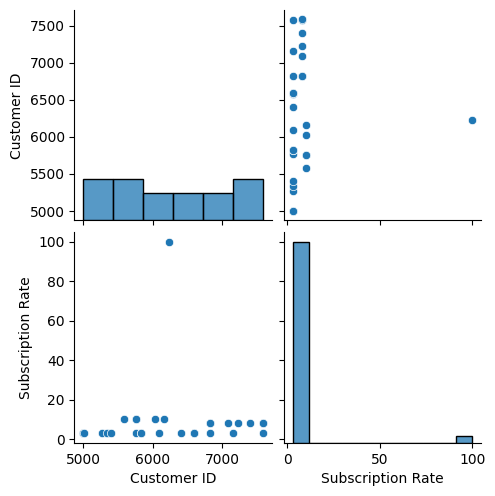

In [151]:
sns.pairplot(customers)


In [152]:
customers[customers["Subscription Rate"]>50]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount,Cancellation Date
15,6229,Symphony Rhodes,rhodes.symphony@email.com,2023-04-06,Premium (No Ads),99.99,No,2023-06-02


In [153]:
customers.loc[15,"Subscription Rate"] = 9.99

In [154]:
customers["Member Since"].dt.year.value_counts()

Member Since
2023    30
Name: count, dtype: int64

In [155]:
customers["Cancellation Date"].dt.year.value_counts()

Cancellation Date
2023.0    13
Name: count, dtype: int64

### c. Create New Columns

We are going to create a new column that shows whether the customer has cancelled or not:

* Cancelled: whether a customer cancelled or not

In [156]:
customers["Cancelled"] = np.where(customers["Cancellation Date"].isna(), 0, 1)

In [157]:
customers.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,No,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,No,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,No,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,No,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,No,NaT,0


## 4. EDA

We are going to conduct an analysis of the cancelling customers, to gain better insights about them we will determine **how long were they member before cancellation** and tell if **having a discount** or not had any influence in cancellation rates.

In [158]:
# How long were customers members before they cancelled?
(customers["Cancellation Date"] - customers["Member Since"]).mean()


Timedelta('46 days 07:23:04.615384')

In [159]:
# Cancellation rate for those who had a discount
(customers[(customers["Cancelled"] == 1) & (customers["Discount"] == "Yes")].shape[0] /
customers[customers["Discount"] == "Yes"].shape[0])

0.8571428571428571

In [160]:
# Cancellation rate for those who did not have a discount
(customers[(customers["Cancelled"] == 1) & (customers["Discount"] =="No")].shape[0] /
 customers[customers["Discount"] == "No"].shape[0])

0.30434782608695654

<Axes: ylabel='Customer Type'>

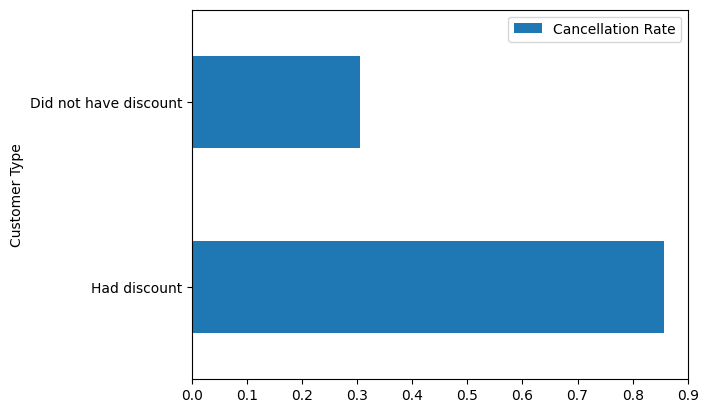

In [161]:
# Visualize the cancellation rate for those with a discount vs those without a discount
pd.DataFrame({
    "Customer Type":["Had discount", "Did not have discount"],
    "Cancellation Rate":[0.8571428571428571, 0.30434782608695654]
}).plot.barh(x="Customer Type", y="Cancellation Rate")


We are going to go over the customers' listening histories, for that, we will gauge how many listening sessions each customer had in the last three months and which were the most popular genres they listen to:


In [162]:
# Split the ID in the audio data so the column can be joined with other tables
audio["Audio ID"] = audio["Audio ID"].astype("int")

In [163]:
audio.head()

,ID,Name,Genre,Popularity,Audio Type,Audio ID
0,Song-101,Dance All Night,Pop,1,Song,101
1,Song-102,Unbreakable Beat,Pop,2,Song,102
2,Song-103,Sunset Boulevard,Pop,5,Song,103
3,Song-104,Glowing Hearts,Pop,10,Song,104
4,Song-105,Pop Rocks,Pop,52,Song,105


In [164]:
audio_complete = listening_history.merge(audio,
                                         on="Audio ID")

In [165]:
audio_complete = audio_complete[["Customer ID", "Session ID", "Audio Order", "Audio ID", "Audio Type_x", "Name", "Genre", "Popularity"]].rename(columns={"Audio Type_x": "Audio Type"})

In [166]:
audio_complete

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Name,Genre,Popularity
0,5001,100520,1,101,Song,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Unbreakable Beat,Pop,2
2,5001,100520,3,103,Song,Sunset Boulevard,Pop,5
3,5001,100520,4,104,Song,Glowing Hearts,Pop,10
4,5001,100520,5,105,Song,Pop Rocks,Pop,52
...,...,...,...,...,...,...,...,...
500,7579,111282,4,111,Song,Moonlit Serenade,Jazz,63
501,6588,111286,1,201,Podcast,Jokes on Jokes,Comedy,2
502,5763,111333,1,110,Song,Boss Moves,Hip Hop,28
503,5763,111333,2,108,Song,Chase the Dream,Hip Hop,4


In [167]:
# The number of listening sessions that each customer had in the past 3 months
audio_complete.groupby("Customer ID")["Session ID"].nunique()

Customer ID
5001    8
5002    4
5004    1
5267    7
5338    4
5404    1
5581    3
5759    2
5761    3
5763    6
5826    3
5827    1
6029    2
6092    3
6163    3
6229    2
6406    3
6584    2
6586    2
6588    3
6821    2
6822    3
6824    4
7087    3
7158    3
7224    4
7401    3
7579    2
7581    2
7583    1
Name: Session ID, dtype: int64

<Axes: ylabel='Frequency'>

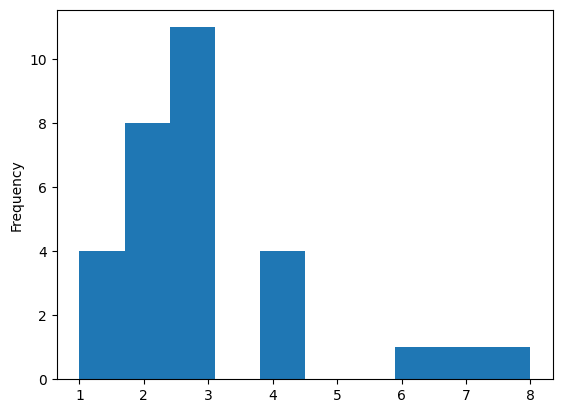

In [168]:
audio_complete.groupby("Customer ID")["Session ID"].nunique().plot.hist()

In [169]:
# The most popular genres that customers listened to
audio_complete.Genre.value_counts()

Genre
Pop           267
Hip Hop        88
Country        68
Jazz           48
Comedy         19
True Crime     15
Name: count, dtype: int64

## 5. Prep for Modeling

Now we are at the last stage of our process, we are going to create a DataFrame that is ready for modeling, each row of the DataFrame will represent a customer, the modeling DataFrame will have the following fields:

* Customer ID
* Whether a customer cancelled or not
* Whether a customer received a discount or not
* The number of listening sessions
* Percent of listening history consisting of Pop
* Percent of listening history consisting of Podcasts

In [170]:
modeling_df = customers[["Customer ID", "Cancelled", "Discount"]]
modeling_df

,Customer ID,Cancelled,Discount
0,5001,0,No
1,5002,0,No
2,5004,1,No
3,5267,0,No
4,5338,0,No
5,5404,1,No
6,5581,0,No
7,5759,1,No
8,5761,0,No
9,5763,0,No


In [171]:
# Calculate the number of listening sessions for each customer
listening_sessions = audio_complete.groupby("Customer ID")["Session ID"].nunique()
listening_sessions

Customer ID
5001    8
5002    4
5004    1
5267    7
5338    4
5404    1
5581    3
5759    2
5761    3
5763    6
5826    3
5827    1
6029    2
6092    3
6163    3
6229    2
6406    3
6584    2
6586    2
6588    3
6821    2
6822    3
6824    4
7087    3
7158    3
7224    4
7401    3
7579    2
7581    2
7583    1
Name: Session ID, dtype: int64

In [172]:
modeling_df = modeling_df.merge(listening_sessions,
                                on="Customer ID",
                                how="left")
modeling_df.rename(columns={"Session ID":"Number of sessions"})

,Customer ID,Cancelled,Discount,Number of sessions
0,5001,0,No,8
1,5002,0,No,4
2,5004,1,No,1
3,5267,0,No,7
4,5338,0,No,4
5,5404,1,No,1
6,5581,0,No,3
7,5759,1,No,2
8,5761,0,No,3
9,5763,0,No,6


In [173]:
# Percent pop
genre_dummies = pd.get_dummies(audio_complete["Genre"]).astype("int")
genre = pd.concat([audio_complete["Customer ID"], genre_dummies],
                  axis=1).groupby("Customer ID").sum()
genre["Total"] = genre.sum(axis=1)
genre = genre.reset_index()

In [174]:
modeling_df["pop_pct"] = (genre["Pop"] / genre["Total"]).round(2) * 100
modeling_df

,Customer ID,Cancelled,Discount,Session ID,pop_pct
0,5001,0,No,8,57.0
1,5002,0,No,4,0.0
2,5004,1,No,1,100.0
3,5267,0,No,7,51.0
4,5338,0,No,4,0.0
5,5404,1,No,1,100.0
6,5581,0,No,3,0.0
7,5759,1,No,2,100.0
8,5761,0,No,3,0.0
9,5763,0,No,6,65.0


In [175]:
# Percent podcasts
modeling_df["podcast_pct"] = (((genre["Comedy"] + genre["True Crime"])/genre["Total"]) * 100).round(2)
modeling_df = modeling_df.rename(columns = {"Session ID":"num of listening sessions"})

In [176]:
modeling_df["Discount"] = np.where(modeling_df["Discount"] == "Yes", 1, 0)

We are now ready to decide which variables do a good work predicting the customer cancellations, the insights we could extract are the following:

* Having a discount and listening to more pop music seems to correlate to more cancellations.
* The more listening sessions the less cancellations.

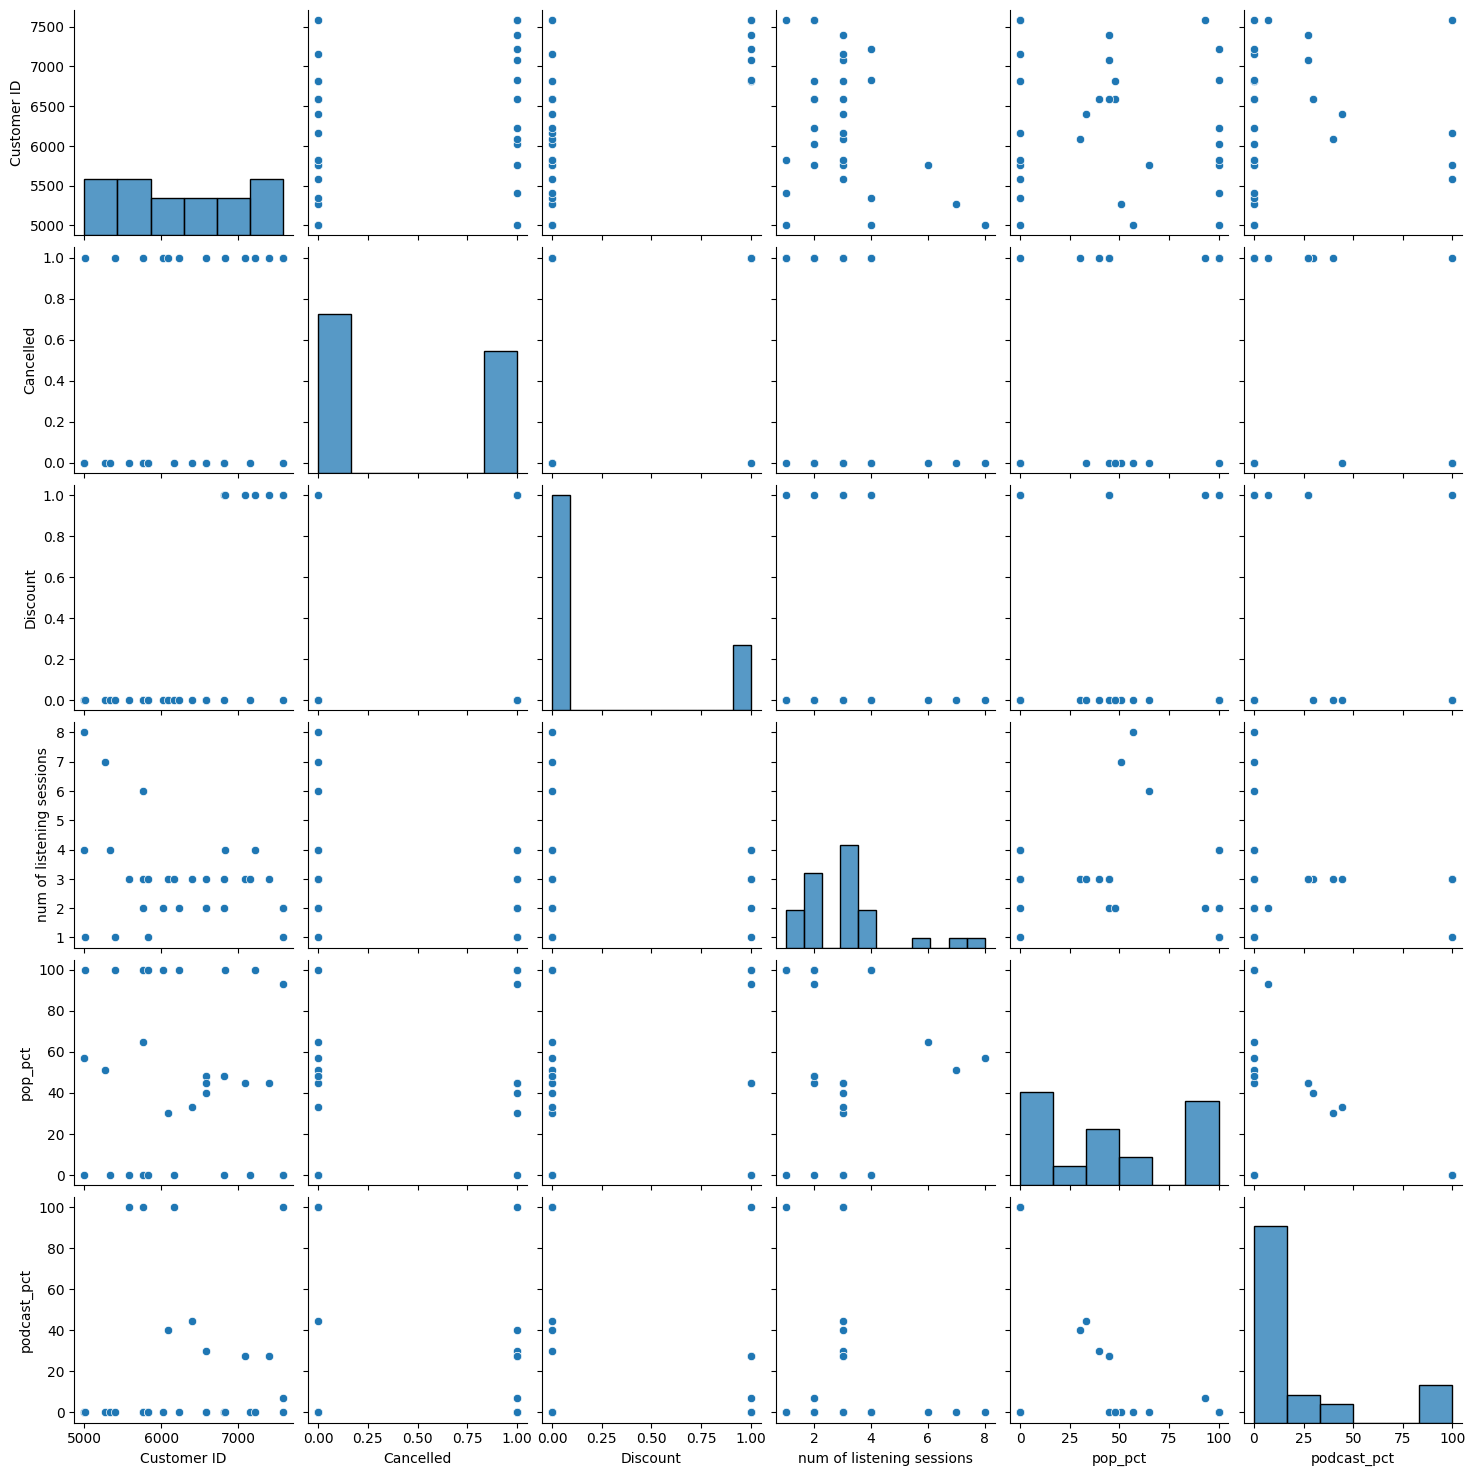

In [177]:
sns.pairplot(modeling_df)

In [178]:
modeling_df.corr()

,Customer ID,Cancelled,Discount,num of listening sessions,pop_pct,podcast_pct
Customer ID,1.000000,0.269942,0.648514,-0.337083,-0.077422,0.083072
Cancelled,0.269942,1.000000,0.471825,-0.333739,0.584480,-0.035419
Discount,0.648514,0.471825,1.000000,-0.048877,0.111384,0.062925
num of listening sessions,-0.337083,-0.333739,-0.048877,1.000000,-0.129659,-0.125458
pop_pct,-0.077422,0.584480,0.111384,-0.129659,1.000000,-0.487597
podcast_pct,0.083072,-0.035419,0.062925,-0.125458,-0.487597,1.000000
